In [1]:
import pandas as pd
import numpy as np
import re

secop_df = pd.read_parquet('secop_bienes.parquet')
print('Filas:', secop_df.shape[0])
print('Columnas:', secop_df.shape[1])

Filas: 196391
Columnas: 36


In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
secop_df.columns

Index(['id_contrato', 'nombre_entidad', 'departamento', 'ciudad', 'orden',
       'sector', 'rama', 'entidad_centralizada', 'tipo_de_contrato',
       'modalidad_de_contratacion', 'codigo_de_categoria_principal',
       'objeto_del_contrato', 'fecha_de_firma', 'fecha_de_inicio_del_contrato',
       'fecha_de_fin_del_contrato', 'duraci_n_del_contrato',
       'condiciones_de_entrega', 'proveedor_adjudicado', 'documento_proveedor',
       'es_pyme', 'es_grupo', 'g_nero_representante_legal',
       'nacionalidad_representante_legal', 'valor_del_contrato',
       'valor_pagado', 'valor_facturado', 'valor_pendiente_de_pago',
       'dias_adicionados', 'habilita_pago_adelantado',
       'el_contrato_puede_ser_prorrogado', 'origen_de_los_recursos',
       'destino_gasto', 'estado_contrato', 'liquidaci_n',
       'obligaci_n_ambiental', 'urlproceso'],
      dtype='str')

In [3]:
secop_df.dtypes

id_contrato                                    str
nombre_entidad                                 str
departamento                                   str
ciudad                                         str
orden                                          str
sector                                         str
rama                                           str
entidad_centralizada                           str
tipo_de_contrato                               str
modalidad_de_contratacion                      str
codigo_de_categoria_principal                  str
objeto_del_contrato                            str
fecha_de_firma                      datetime64[us]
fecha_de_inicio_del_contrato        datetime64[us]
fecha_de_fin_del_contrato           datetime64[us]
duraci_n_del_contrato                          str
condiciones_de_entrega                         str
proveedor_adjudicado                           str
documento_proveedor                            str
es_pyme                        

In [4]:
def fragmento_sospechoso(variable_temporal_columna):
    fragmentos = variable_temporal_columna.split('_')
    return any(len(frag) == 1 for frag in fragmentos)

columnas_sospechosas = [col for col in secop_df.columns if fragmento_sospechoso(col)]

print("Columnas con posible problema de encoding:")
for col in columnas_sospechosas:
    print(col)

Columnas con posible problema de encoding:
duraci_n_del_contrato
g_nero_representante_legal
liquidaci_n
obligaci_n_ambiental


In [5]:
correccion_columnas = {
    'duraci_n_del_contrato': 'duracion_del_contrato',
    'g_nero_representante_legal': 'genero_representante_legal',
    'liquidaci_n': 'liquidacion',
    'obligaci_n_ambiental': 'obligacion_ambiental',
}

secop_df = secop_df.rename(columns=correccion_columnas)
print("Columnas corregidas:")
for original, corregida in correccion_columnas.items():
    print(f"  {original} -> {corregida}")

Columnas corregidas:
  duraci_n_del_contrato -> duracion_del_contrato
  g_nero_representante_legal -> genero_representante_legal
  liquidaci_n -> liquidacion
  obligaci_n_ambiental -> obligacion_ambiental


## Validación sistemática de calidad de datos

Antes de fijar el Top 5 de atributos, revisamos de forma sistemática (no solo mirando `describe()`) los problemas de calidad típicos: nulos, fechas fuera de rango o inconsistentes entre sí, valores negativos donde no deberían existir, y categorías "centinela" (`No Definido`/`No aplica`) que en realidad son valores faltantes disfrazados de texto.

In [6]:
print("Valores nulos por columna (solo columnas con al menos uno):")
nulos = secop_df.isna().sum()
print(nulos[nulos > 0])

rango_min, rango_max = '2016-01-01', '2025-12-31'
cols_fecha = ['fecha_de_firma', 'fecha_de_inicio_del_contrato', 'fecha_de_fin_del_contrato']

print("\nFechas fuera del rango esperado (2016-2025):")
for col in cols_fecha:
    fuera_rango = ((secop_df[col] < rango_min) | (secop_df[col] > rango_max)).sum()
    print(f"  {col}: {fuera_rango} filas fuera de rango (min={secop_df[col].min()}, max={secop_df[col].max()})")

fin_antes_inicio = (secop_df['fecha_de_fin_del_contrato'] < secop_df['fecha_de_inicio_del_contrato']).sum()
print(f"\nFilas con fecha_de_fin_del_contrato anterior a fecha_de_inicio_del_contrato: {fin_antes_inicio}")

print("\nValores negativos en columnas monetarias:")
cols_valor = ['valor_del_contrato', 'valor_pagado', 'valor_facturado', 'valor_pendiente_de_pago']
for col in cols_valor:
    negativos = (secop_df[col] < 0).sum()
    print(f"  {col}: {negativos} filas negativas")

print("\nCategorías centinela ('No Definido'/'No aplica') por columna de texto:")
columnas_texto = secop_df.select_dtypes(exclude=['number', 'datetime']).columns
centinelas = {'no definido', 'no aplica'}
for col in columnas_texto:
    conteo = secop_df[col].str.strip().str.lower().isin(centinelas).sum()
    if conteo > 0:
        print(f"  {col}: {conteo}")

Valores nulos por columna (solo columnas con al menos uno):
fecha_de_inicio_del_contrato    2440
documento_proveedor                4
dtype: int64

Fechas fuera del rango esperado (2016-2025):
  fecha_de_firma: 0 filas fuera de rango (min=2019-01-01 00:00:00, max=2025-12-31 00:00:00)
  fecha_de_inicio_del_contrato: 378 filas fuera de rango (min=2016-06-27 00:00:00, max=2026-12-16 00:00:00)
  fecha_de_fin_del_contrato: 5605 filas fuera de rango (min=0202-12-31 00:00:00, max=2065-01-31 00:00:00)

Filas con fecha_de_fin_del_contrato anterior a fecha_de_inicio_del_contrato: 125

Valores negativos en columnas monetarias:
  valor_del_contrato: 0 filas negativas
  valor_pagado: 0 filas negativas
  valor_facturado: 0 filas negativas
  valor_pendiente_de_pago: 144 filas negativas

Categorías centinela ('No Definido'/'No aplica') por columna de texto:
  departamento: 7510
  ciudad: 41672
  orden: 9
  sector: 9
  rama: 9
  objeto_del_contrato: 1109
  duracion_del_contrato: 9490
  condiciones_de_e

### Tratamiento aplicado

Con base en los hallazgos anteriores, se decidió lo siguiente (sin eliminar filas, para no perder información válida de otras columnas):

1. **Categorías centinela ("No Definido"/"No aplica")** → se estandarizan a `NA` explícito en todas las columnas de texto. Se trataban como una categoría más en los `value_counts`, pero son valores faltantes disfrazados; el caso más notorio es `condiciones_de_entrega` con 25.4% de filas afectadas.
2. **Fechas fuera de rango o inconsistentes** (`fecha_de_inicio`/`fecha_de_fin` fuera de 2016–2025, o `fecha_de_fin < fecha_de_inicio`) → no se eliminan ni se imputan; se marcan con una columna booleana `fecha_sospechosa` para poder excluirlas puntualmente de análisis de duración/plazo más adelante, sin perder el resto de la fila.
3. **`valor_pendiente_de_pago` negativo (144 filas)** → se investigó el patrón: el 100% de esos casos tiene `valor_pagado > valor_del_contrato`, es decir, sobrepago real y no un error de captura. Se deja el valor tal cual; es una señal de posible interés para supervisión, no un dato a corregir.

In [7]:
centinelas_texto = ['no definido', 'no aplica']
columnas_texto = secop_df.select_dtypes(exclude=['number', 'datetime']).columns

for col in columnas_texto:
    es_centinela = secop_df[col].str.strip().str.lower().isin(centinelas_texto)
    secop_df.loc[es_centinela, col] = pd.NA

print("Categorías centinela convertidas a NA. Nulos por columna (top 10):")
nulos_actualizados = secop_df.isna().sum()
print(nulos_actualizados[nulos_actualizados > 0].sort_values(ascending=False).head(10))

Categorías centinela convertidas a NA. Nulos por columna (top 10):
condiciones_de_entrega          49971
ciudad                          41672
genero_representante_legal      35822
habilita_pago_adelantado        28507
duracion_del_contrato            9490
departamento                     7510
fecha_de_inicio_del_contrato     2440
documento_proveedor              1569
objeto_del_contrato              1109
destino_gasto                     911
dtype: int64


In [8]:
rango_min, rango_max = '2016-01-01', '2025-12-31'

secop_df['fecha_sospechosa'] = (
    (secop_df['fecha_de_inicio_del_contrato'] < rango_min) |
    (secop_df['fecha_de_inicio_del_contrato'] > rango_max) |
    (secop_df['fecha_de_fin_del_contrato'] < rango_min) |
    (secop_df['fecha_de_fin_del_contrato'] > rango_max) |
    (secop_df['fecha_de_fin_del_contrato'] < secop_df['fecha_de_inicio_del_contrato'])
)

print("Contratos marcados con fecha_sospechosa:", secop_df['fecha_sospechosa'].sum(),
      f"({secop_df['fecha_sospechosa'].mean():.1%} del total)")

Contratos marcados con fecha_sospechosa: 5730 (2.9% del total)


## Top 5 de atributos clave

El taller señala explícitamente que el **valor**, la **modalidad de contratación**, el **sector**, el **tipo de entidad** y el **destino del gasto** son las características que se espera estén asociadas con desviaciones en la ejecución de un contrato (adiciones de plazo, presupuesto no ejecutado, cierre sin liquidar). Por eso estos son los 5 atributos priorizados para el análisis univariado inicial:

1. **`valor_del_contrato`** — tamaño económico del contrato; a mayor valor, mayor impacto potencial de una desviación.
2. **`sector`** — área de gobierno a la que pertenece la entidad contratante.
3. **`modalidad_de_contratacion`** — mecanismo usado para adjudicar el contrato (licitación, mínima cuantía, etc.), asociado en la literatura de contratación pública a distintos niveles de riesgo y control.
4. **`orden`** — tipo de entidad (Nacional vs. Territorial), relevante porque la capacidad de supervisión varía según el nivel de gobierno.
5. **`destino_gasto`** — si el gasto es de funcionamiento o de inversión, lo cual afecta el tipo de seguimiento presupuestal esperado.

### Validación cuantitativa del Top 5

El Top 5 anterior se justificó con el enunciado del taller. Aquí lo respaldamos con datos: construimos la variable binaria `desviado` (definida en la Estrategia de análisis) y medimos qué tanto cada atributo del Top 5 discrimina entre contratos desviados y no desviados, usando solo tablas cruzadas y correlación (Pearson/Spearman) — lo visto en la clase de EDA.

In [ ]:
# Contratos cuyo estado indica que ya terminaron (cerrado o terminado); es la base para evaluar las señales 2 y 3
estados_cierre = secop_df['estado_contrato'].str.lower().isin(['cerrado', 'terminado'])

# Señal 1: se le añadieron días de plazo al contrato respecto a lo pactado inicialmente
adicion_plazo = secop_df['dias_adicionados'] > 0

# Señal 2: contrato ya cerrado/terminado pero con más del 10% de su valor todavía sin pagar (presupuesto no ejecutado)
# El umbral del 10% se validó probando entre 5% y 30%: la tasa resultante varía menos de 2 puntos porcentuales,
# así que la definición no es sensible al valor exacto del umbral
presupuesto_no_ejecutado = (
    estados_cierre &
    (secop_df['valor_pendiente_de_pago'] / secop_df['valor_del_contrato'].replace(0, np.nan) > 0.1)
).fillna(False)

# Señal 3: contrato ya cerrado/terminado pero sin liquidar formalmente
cierre_sin_liquidar = estados_cierre & (secop_df['liquidacion'] == 'No')

# "Desviado" = el contrato tiene al menos una de las tres señales de ejecución fuera de lo planeado
secop_df['desviado'] = adicion_plazo | presupuesto_no_ejecutado | cierre_sin_liquidar

# Cuántos contratos quedan marcados como desviados en total
print("Contratos desviados:", secop_df['desviado'].sum(), f"({secop_df['desviado'].mean():.1%})")

# Cuánto aporta cada señal por separado, para entender qué está impulsando ese porcentaje
print("Solo adición de plazo:", f"{adicion_plazo.mean():.1%}")
print("Solo presupuesto no ejecutado:", f"{presupuesto_no_ejecutado.mean():.1%}")
print("Solo cierre sin liquidar:", f"{cierre_sin_liquidar.mean():.1%}")
print("Contratos ya cerrados/terminados (universo de las señales 2 y 3):", f"{estados_cierre.mean():.1%}")

In [ ]:
# Para cada atributo categórico del Top 5, medimos qué tanto varía la tasa de desviación entre sus categorías
for col in ['sector', 'modalidad_de_contratacion', 'orden', 'destino_gasto']:
    # Tasa de desviación (promedio de la columna booleana "desviado") agrupada por cada categoría, de mayor a menor
    tasas = secop_df.groupby(col)['desviado'].mean().sort_values(ascending=False)
    # Cuántos contratos tiene cada categoría, para no confundir ruido de muestra chica con una señal real
    tamanos = secop_df.groupby(col).size()
    # Excluimos categorías con menos de 30 contratos al calcular el rango (su tasa no es confiable)
    tasas_confiables = tasas[tamanos[tasas.index] >= 30]
    # Rango = diferencia entre la tasa más alta y la más baja; entre más grande, más discrimina ese atributo
    print(f"\n{col}: rango de tasas (categorías con >=30 contratos) = {(tasas_confiables.max() - tasas_confiables.min()):.1%}")
    # Mostramos la tabla completa (tasa + tamaño de muestra) para poder juzgar cada categoría con contexto
    print(pd.concat([tasas, tamanos], axis=1, keys=['tasa_desviacion', 'n_contratos']).sort_values('tasa_desviacion', ascending=False))

In [ ]:
# Correlación de Pearson: mide relación LINEAL entre valor_del_contrato y la variable binaria "desviado" (0/1)
correlacion_pearson = secop_df['valor_del_contrato'].corr(secop_df['desviado'].astype(int))

# Correlación de Spearman calculada manualmente por rangos, porque scipy no está instalado en este entorno:
# Spearman es equivalente a aplicar Pearson sobre los RANGOS de cada variable en vez de sus valores crudos
correlacion_spearman = secop_df['valor_del_contrato'].rank().corr(secop_df['desviado'].astype(int).rank())

print("Correlación Pearson valor_del_contrato vs desviado:", round(correlacion_pearson, 4))
print("Correlación Spearman valor_del_contrato vs desviado:", round(correlacion_spearman, 4))

**Interpretación:**

- 47.9% de los contratos quedan marcados como "desviados". El principal impulsor es el cierre sin liquidar (28.5% de todos los contratos), seguido de presupuesto no ejecutado (24.0%) y, muy por debajo, adición de plazo (9.5%).
- `sector` es el atributo categórico que más discrimina: 37.7 puntos porcentuales de rango entre categorías con muestra confiable (Ciencia y Tecnología 71.7% vs. Hacienda y Crédito Público 37.1%).
- `orden` también discrimina de forma clara: Corporación Autónoma (59.6%) vs. Territorial (45.8%), 13.8 puntos de rango.
- `destino_gasto` y `modalidad_de_contratacion` discriminan menos (19.1 y 16.4 puntos respectivamente), pero siguen siendo consistentes con incluirlos en el Top 5.
- **Hallazgo no significativo, y por eso relevante de reportar:** `valor_del_contrato` prácticamente no está correlacionado con la desviación (Pearson = -0.0022, Spearman = 0.0746). Contradice la intuición de que "contratos más grandes son más riesgosos" — el tamaño del contrato, por sí solo, no explica la desviación en este dataset.

In [9]:
secop_df.head()

,id_contrato,nombre_entidad,departamento,ciudad,orden,sector,rama,entidad_centralizada,tipo_de_contrato,modalidad_de_contratacion,codigo_de_categoria_principal,objeto_del_contrato,fecha_de_firma,fecha_de_inicio_del_contrato,fecha_de_fin_del_contrato,duracion_del_contrato,condiciones_de_entrega,proveedor_adjudicado,documento_proveedor,es_pyme,es_grupo,genero_representante_legal,nacionalidad_representante_legal,valor_del_contrato,valor_pagado,valor_facturado,valor_pendiente_de_pago,dias_adicionados,habilita_pago_adelantado,el_contrato_puede_ser_prorrogado,origen_de_los_recursos,destino_gasto,estado_contrato,liquidacion,obligacion_ambiental,urlproceso,fecha_sospechosa
0,CO1.PCCNTR.1000001,PARQUES NACIONALES NATURALES DE COLOMBIA - DIRECCION TERRITORIAL AMAZONIA,Distrito Capital de Bogotá,NaN,Territorial,Ambiente y Desarrollo Sostenible,Ejecutivo,Centralizada,Suministros,Mínima cuantía,V1.50161509,Contratar a monto agotable por el sistema de precios unitarios; sin formula de reajuste el suministro de elementos de aseo y limpieza e insumos de cafetería y restaurante; para los Parques Nacionales Naturales de Amacayacu; Cahuinarí; Río Puré y Yaigojé Apaporis,2019-06-19,2019-06-18,2019-12-31,NaN,Como acordado previamente,INDUSTRIAS GUERRERO Y COMPAÑIA S.A.S.,830130048,Si,No,NaN,CO,17897916.0,17896237,17896237,1679,0,NaN,Si,Distribuido,Funcionamiento,Cerrado,Si,No,{'url': 'https://community.secop.gov.co/Public/Tendering/OpportunityDetail/Index?noticeUID=CO1.NTC.846428&isFromPublicArea=True&isModal=true&asPopupView=true'},False
1,CO1.PCCNTR.1000507,AGENCIA LOGISTICA DE LAS FUERZAS MILITARES,Distrito Capital de Bogotá,Bogotá,Nacional,defensa,Ejecutivo,Centralizada,Suministros,Selección Abreviada de Menor Cuantía,V1.50131612,SUMINISTRO DE HUEVOS CON DESTINO A LOS COMEDORES DE TROPA DE LA BR-4 Y BR-14; ADMINISTRADOS POR LA AGENCIA LOGÍSTICA DE LAS FUERZAS MILITARES REGIONAL ANTIOQUIA CHOCO Y OTRAS POSIBLES UNIDADES QUE LO REQUIERAN,2019-06-23,2019-06-13,2019-11-29,Dia(s),Transporte incluido,Distribuidora Antioqueña AM,21788564,Si,No,Mujer,CO,390000000.0,389999685,389999685,315,0,No,No,Distribuido,Funcionamiento,Cerrado,Si,No,{'url': 'https://community.secop.gov.co/Public/Tendering/OpportunityDetail/Index?noticeUID=CO1.NTC.841446&isFromPublicArea=True&isModal=true&asPopupView=true'},False
2,CO1.PCCNTR.1000901,FUERZA AEROESPACIAL COLOMBIANA,Distrito Capital de Bogotá,Bogotá,Nacional,defensa,Ejecutivo,Centralizada,Compraventa,Mínima cuantía,V1.53102701,ADQUISICIÓN DE PRESILLAS BORDADAS AZULES EN CANUTILLO PARA OFICIALES DE INSIGNIA DE LA FUERZA AÉREA COLOMBIANA CONFORME ANEXO TECNICO,2019-06-18,2019-06-24,2019-09-30,NaN,DAP - Entregado en un punto (lugar de destino convenido),FANNY JANETH GUTIERREZ PRIETO,20484821,No,No,Mujer,CO,11970000.0,11970000,11970000,0,0,NaN,Si,Distribuido,Funcionamiento,terminado,No,No,{'url': 'https://community.secop.gov.co/Public/Tendering/OpportunityDetail/Index?noticeUID=CO1.NTC.846657&isFromPublicArea=True&isModal=true&asPopupView=true'},False
3,CO1.PCCNTR.1000908,AGENCIA LOGISTICA DE LAS FUERZAS MILITARES,Distrito Capital de Bogotá,Bogotá,Nacional,defensa,Ejecutivo,Centralizada,Compraventa,Licitación pública,V1.41115300,ADQUISICIÓN DE UN SISTEMA DE SONAR 3D DE ALTA RESOLUCIÓN CON DESTINO AL DEPARTAMENTO DE BUCEO Y SALVAMENTO,2019-07-25,2019-07-12,2019-11-30,Dia(s),Como acordado previamente,CASCO ANTIGUO,76044753,No,No,Otro,CO,733992000.0,0,0,733992000,0,No,No,Distribuido,Funcionamiento,Cerrado,Si,No,{'url': 'https://community.secop.gov.co/Public/Tendering/OpportunityDetail/Index?noticeUID=CO1.NTC.826239&isFromPublicArea=True&isModal=true&asPopupView=true'},False
4,CO1.PCCNTR.1000911,PARQUES NACIONALES NATURALES DE COLOMBIA - DIRECCION TERRITORIAL CARIBE,Bolívar,Cartagena,Territorial,Ambiente y Desarrollo Sostenible,Ejecutivo,Centralizada,Suministros,Mínima cuantía,V1.92121701,Suministro de equipos para la instalación de todas las cámaras necesarias para el monitoreo; para ser instalados en\nlas sedes operativas 

In [10]:
secop_df.tail

<bound method NDFrame.tail of                id_contrato  \
0       CO1.PCCNTR.1000001   
1       CO1.PCCNTR.1000507   
2       CO1.PCCNTR.1000901   
3       CO1.PCCNTR.1000908   
4       CO1.PCCNTR.1000911   
...                    ...   
196386   CO1.PCCNTR.999805   
196387   CO1.PCCNTR.999806   
196388   CO1.PCCNTR.999807   
196389   CO1.PCCNTR.999810   
196390   CO1.PCCNTR.999902   

                                                                    nombre_entidad  \
0       PARQUES NACIONALES NATURALES DE COLOMBIA - DIRECCION  TERRITORIAL AMAZONIA   
1                                       AGENCIA LOGISTICA DE LAS FUERZAS MILITARES   
2                                                   FUERZA AEROESPACIAL COLOMBIANA   
3                                       AGENCIA LOGISTICA DE LAS FUERZAS MILITARES   
4          PARQUES NACIONALES NATURALES DE COLOMBIA - DIRECCION TERRITORIAL CARIBE   
...                                                                            ...   
196386 

In [11]:
# 1. ¿Cuántos IDs únicos hay vs. cuántas filas totales?
print("Total de filas:", len(secop_df))
print("IDs únicos:", secop_df['id_contrato'].nunique())

# 2. Si los números no coinciden, hay duplicados
duplicados = secop_df['id_contrato'].duplicated().sum()
print("Filas con id_contrato repetido:", duplicados)

Total de filas: 196391
IDs únicos: 196391
Filas con id_contrato repetido: 0


In [12]:
secop_df.sample(10)

,id_contrato,nombre_entidad,departamento,ciudad,orden,sector,rama,entidad_centralizada,tipo_de_contrato,modalidad_de_contratacion,codigo_de_categoria_principal,objeto_del_contrato,fecha_de_firma,fecha_de_inicio_del_contrato,fecha_de_fin_del_contrato,duracion_del_contrato,condiciones_de_entrega,proveedor_adjudicado,documento_proveedor,es_pyme,es_grupo,genero_representante_legal,nacionalidad_representante_legal,valor_del_contrato,valor_pagado,valor_facturado,valor_pendiente_de_pago,dias_adicionados,habilita_pago_adelantado,el_contrato_puede_ser_prorrogado,origen_de_los_recursos,destino_gasto,estado_contrato,liquidacion,obligacion_ambiental,urlproceso,fecha_sospechosa
73910,CO1.PCCNTR.4184171,FUERZA AEROESPACIAL COLOMBIANA,Distrito Capital de Bogotá,Bogotá,Nacional,defensa,Ejecutivo,Centralizada,Compraventa,Contratación Directa (con ofertas),V1.42201712,Adquisición de un ecógrafo multipropósito para la Jefatura de Salud,2022-11-09,2022-11-14,2022-11-24,5 Mes(es),Como acordado previamente,Top Medical Systems s.a,860350543,No,No,Hombre,CO,260000000.0,260000000,260000000,0,0,No,Si,Distribuido,Funcionamiento,Cerrado,No,No,{'url': 'https://community.secop.gov.co/Public/Tendering/OpportunityDetail/Index?noticeUID=CO1.NTC.3441212&isFromPublicArea=True&isModal=true&asPopupView=true'},False
51210,CO1.PCCNTR.3116508,ALCALDIA LOCAL DE FONTIBON,Distrito Capital de Bogotá,Bogotá,Territorial,Servicio Público,Ejecutivo,Centralizada,Compraventa,Selección abreviada subasta inversa,V1.52161500,ADQUIRIR ELEMENTOS DE CÓMPUTO Y TECNOLOGÍA PARA LAS INSTITUCIONES EDUCATIVAS OFICIALES DE LA LOCALIDAD DE FONTIBÓN,2021-12-22,2022-02-07,2022-05-06,3 Mes(es),A convenir,REDCOMPUTO LTDA,830016004,Si,No,Hombre,CO,315273000.0,0,315183148,315273000,0,No,Si,Recursos Propios,Inversión,En ejecución,Si,No,{'url': 'https://community.secop.gov.co/Public/Tendering/OpportunityDetail/Index?noticeUID=CO1.NTC.2401804&isFromPublicArea=True&isModal=true&asPopupView=true'},False
83278,CO1.PCCNTR.4660142,EMPRESA DE SERVICIOS PÚBLICOS DE PUERTO SALGAR CUNDINAMARCA,Cundinamarca,Puerto Salgar,Territorial,No aplica/No pertenece,Ejecutivo,Centralizada,Suministros,Contratación régimen especial,V1.72102900,ADQUISICIÓN DE MOTOBOMBA SUMERGIBLE PARA AGUA RESIDUAL PARA LA EMPRESA DE SERVICIOS PÚBLICOS DE PUERTO SALGAR; CUNDINAMARCA,2023-02-22,2023-02-27,2023-03-08,10 Dia(s),NaN,ACFERBO SAS,900387217,Si,No,NaN,CO,5571580.0,5571580,5571580,0,0,No,No,Distribuido,Funcionamiento,En ejecución,No,No,{'url': 'https://community.secop.gov.co/Public/Tendering/OpportunityDetail/Index?noticeUID=CO1.NTC.4038375&isFromPublicArea=True&isModal=true&asPopupView=true'},False
22123,CO1.PCCNTR.1887093,HOSMIL,Distrito Capital de Bogotá,NaN,Nacional,defensa,Ejecutivo,Descentralizada,Compraventa,Selección abreviada subasta inversa,V1.43211500,ADQUISICIÓN DE EQUIPOS DE CÓMPUTO PARA EL HOSPITAL MILITAR. \nLote No. 2: EQUIPOS DE CÓMPUTO TIPO TABLET - PC,2020-11-13,2020-11-23,2021-04-30,84 Dia(s),NaN,COMERCIALIZADORA SERLE.COM,800089897,Si,No,Mujer,CO,34020910.0,0,0,34020910,0,No,No,Distribuido,Funcionamiento,Cerrado,No,No,{'url': 'https://community.secop.gov.co/Public/Tendering/OpportunityDetail/Index?noticeUID=CO1.NTC.1414914&isFromPublicArea=True&isModal=true&asPopupView=true'},False
185541,CO1.PCCNTR.8661831,ALCALDÍA MUNICIPAL DE ROLDANILLO,Valle del Cauca,Roldanillo,Nacional,Servicio Público,Ejecutivo,Centralizada,Compraventa,Mínima cuantía,V1.53101600,COMPRA DE DOTACIÓN LEGAL DE VESTUARIO Y CALZADO PARA LOS AGENTES DE TRÁNSITO QUE LABORAN EN LA ALCALDIA DEL MUNICIPIO DE ROLDANILLO - VALLE DEL CAUCA - VIGENCIA 2025,2025-12-02,2025-12-02,2025-12-13,10 Dia(s),NaN,ESTRATEGIAS METODOS Y DISCIPLINAS SAS,901476047,Si,No,Hombre,CO,25297732.0,0,25297732,25297732,0,No,No,Distribuido,Funcionamiento,En ejecución,No,No,{'url': 'https://community.secop.gov.co/Public/Tendering/OpportunityDetail/Index?noticeUID=CO1.NTC.9187660&isFromPublicArea=True&isModal=true&asPopupView=true'},False
156810,CO1.PCCNTR.7767983,CONCEJO MUNIC

In [13]:
secop_df.describe()

,fecha_de_firma,fecha_de_inicio_del_contrato,fecha_de_fin_del_contrato,valor_del_contrato,valor_pagado,valor_facturado,valor_pendiente_de_pago,dias_adicionados
count,196391,193951,196391,1.963910e+05,1.963910e+05,1.963910e+05,1.963910e+05,196391.000000
mean,2023-02-27 22:45:53.539622,2023-03-01 13:02:29.326376,2023-06-11 04:37:50.596921,6.582426e+10,1.194911e+08,1.484092e+08,6.570476e+10,5.107485
min,2019-01-01 00:00:00,2016-06-27 00:00:00,0202-12-31 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,-8.418488e+07,0.000000
25%,2021-09-10 00:00:00,2021-09-17 00:00:00,2021-12-20 00:00:00,1.202121e+07,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
50%,2023-05-30 00:00:00,2023-06-05 00:00:00,2023-10-27 00:00:00,3.360000e+07,0.000000e+00,3.207328e+06,6.717571e+06,0.000000
75%,2024-11-07 00:00:00,2024-11-14 00:00:00,2024-12-31 00:00:00,1.000000e+08,2.812077e+07,3.708622e+07,4.241189e+07,0.000000
max,2025-12-31 00:00:00,2026-12-16 00:00:00,2065-01-31 00:00:00,1.285845e+16,5.944034e+11,5.945032e+11,1.285845e+16,14276.000000
std,NaN,NaN,NaN,2.901535e+13,2.444116e+09,2.969810e+09,2.901535e+13,40.662426


In [14]:
secop_df['sector'].nunique()

25

In [15]:
secop_df['sector'].value_counts()

sector
Servicio Público                                      37390
defensa                                               34585
No aplica/No pertenece                                24465
Salud y Protección Social                             22037
Ley de Justicia                                       20377
Trabajo                                               14759
Educación Nacional                                    10231
Ambiente y Desarrollo Sostenible                       8109
Transporte                                             4655
Cultura                                                2792
deportes                                               2610
Hacienda y Crédito Público                             2441
Industria                                              1807
Vivienda, Ciudad y Territorio                          1497
Planeación                                             1319
agricultura                                            1254
interior                         

In [16]:
secop_df['tipo_de_contrato'].nunique()

2

In [17]:
secop_df['tipo_de_contrato'].value_counts()

tipo_de_contrato
Suministros    106632
Compraventa     89759
Name: count, dtype: int64

In [18]:
secop_df['fecha_de_firma'].dt.year.value_counts().sort_index()

fecha_de_firma
2019    16425
2020    20135
2021    24043
2022    28070
2023    32971
2024    34634
2025    40113
Name: count, dtype: int64

<Axes: >

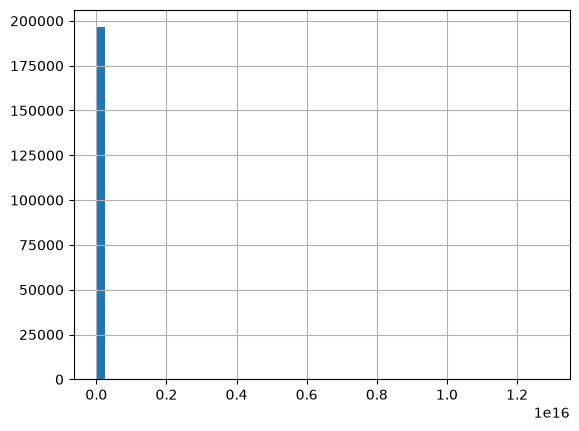

In [19]:
secop_df['valor_del_contrato'].hist(bins=50)

In [20]:
secop_df['valor_del_contrato'].quantile([0.01, 0.25, 0.5, 0.75, 0.99])

0.01    7.010680e+05
0.25    1.202121e+07
0.50    3.360000e+07
0.75    1.000000e+08
0.99    4.118482e+09
Name: valor_del_contrato, dtype: float64

In [21]:
secop_df['modalidad_de_contratacion'].value_counts()

modalidad_de_contratacion
Mínima cuantía                                                 117753
Selección abreviada subasta inversa                             32907
Contratación régimen especial                                   19250
Selección Abreviada de Menor Cuantía                             8822
Contratación régimen especial (con ofertas)                      6154
Contratación Directa (con ofertas)                               5001
Contratación directa                                             3938
Licitación pública                                               2330
Seleccion Abreviada Menor Cuantia Sin Manifestacion Interes       236
Name: count, dtype: int64

In [22]:
secop_df['orden'].value_counts()

orden
Territorial             97293
Nacional                96680
Corporación Autónoma     2409
Name: count, dtype: int64

In [23]:
secop_df['destino_gasto'].value_counts()

destino_gasto
Funcionamiento    117097
Inversión          78383
Name: count, dtype: int64

## Hallazgos

**Pendientes de limpieza detectados y su tratamiento:**

- Nombres de columna con problemas de encoding (`duraci_n_del_contrato`, `g_nero_representante_legal`, `liquidaci_n`, `obligaci_n_ambiental`) — **corregidos** renombrando a `duracion_del_contrato`, `genero_representante_legal`, `liquidacion` y `obligacion_ambiental`, siguiendo la misma convención sin tildes que ya usan las demás columnas.
- La granularidad es una fila = un `id_contrato` único (196,391 filas, sin duplicados).
- Nulos verdaderos: `fecha_de_inicio_del_contrato` (2,440 filas, 1.2%) y `documento_proveedor` (4 filas) — se dejan como `NaN`, sin imputar.
- Fechas fuera de rango o inconsistentes: `fecha_de_inicio_del_contrato` (378 filas fuera de 2016–2025, máx. `2026-12-16`), `fecha_de_fin_del_contrato` (5,605 filas fuera de rango, mín. `0202-12-31`, máx. `2065-01-31`), y 125 filas con `fecha_de_fin < fecha_de_inicio`. **Tratamiento:** no se eliminan filas ni se imputan fechas; se marcan con la columna booleana `fecha_sospechosa` (2.9% del total, 5,730 filas) para poder excluirlas puntualmente de análisis de duración/plazo más adelante sin perder el resto de la información del contrato.
- `valor_pendiente_de_pago` negativo (144 filas): se verificó que el 100% de esos casos tiene `valor_pagado > valor_del_contrato` — es un patrón de sobrepago real, no un error de captura. **Tratamiento:** se deja el valor sin modificar; queda como posible señal de interés para la focalización de supervisión.
- Categorías centinela (`No Definido` / `No aplica`) usadas como texto en vez de nulo real, con tasas de faltantes altas en varias columnas clave: `condiciones_de_entrega` (25.4%), `ciudad` (21.2%), `genero_representante_legal` (18.2%), `habilita_pago_adelantado` (14.5%), `duracion_del_contrato` (4.8%), `departamento` (3.8%), y en menor medida `orden`, `sector`, `rama`, `destino_gasto`, `objeto_del_contrato`, `proveedor_adjudicado`, `documento_proveedor` y `nacionalidad_representante_legal`. **Tratamiento:** estandarizadas a `NA` explícito en todas las columnas de texto, para que dejen de contarse como una categoría de negocio más en los `value_counts` del análisis univariado.

# 2. Estrategia de análisis


**Definición operacional de "desviación" (variable de interés):** un contrato se considera desviado si presenta al menos una de estas tres señales de ejecución fuera de lo planeado:
1. Adición de plazo (`dias_adicionados > 0`).
2. Presupuesto no ejecutado al cierre (contrato cerrado/terminado con `valor_pendiente_de_pago` alto relativo a `valor_del_contrato`).
3. Cierre sin liquidar (`estado_contrato` terminado/cerrado con `liquidacion == 'No'`).

**Métrica de modelo vs. métrica de negocio:** la métrica de modelo es qué tan bien las características del contrato (valor, modalidad, sector, orden, destino del gasto) distinguen contratos desviados de no desviados. La métrica de negocio real es si la oficina de control efectivamente usa esa priorización para enfocar su supervisión limitada — un buen hallazgo estadístico sin adopción práctica no genera valor.

**Hipótesis a contrastar** (de forma descriptiva — tablas cruzadas y comparación de medianas/IQR por grupo, boxplots; el curso no ha cubierto pruebas de significancia formales como chi-cuadrado o t-test, así que no se usan):
- H1: la tasa de desviación varía según `modalidad_de_contratacion`.
- H2: `valor_del_contrato` es mayor en contratos desviados que en no desviados.
- H3: la tasa de desviación varía según `orden` (Nacional vs. Territorial).
- H4: la tasa de desviación varía según `destino_gasto`.
- H5: la tasa de desviación varía según `sector`.

Cada hipótesis se reporta como soportada si la diferencia entre grupos es clara y consistente (cajas de boxplot que no se solapan, o diferencia marcada en la tabla cruzada), y como no soportada si los grupos resultan indistinguibles — reportando ambos casos, no solo los llamativos.

**Técnicas:**
- Univariado: medidas de tendencia central (media/mediana), dispersión (SD y MAD, más robusta dado el sesgo ya observado), forma (asimetría/kurtosis).
- Bivariado/multivariado no gráfico: tablas cruzadas (desviación × modalidad/orden/destino_gasto/sector), correlación de Pearson y Spearman entre `valor_del_contrato` y `dias_adicionados`.
- Regresión lineal: `dias_adicionados` o `valor_pendiente_de_pago` en función de `valor_del_contrato` y variables categóricas, para cuantificar el efecto de cada una manteniendo las demás constantes.
- Visualización: boxplots por categoría, mapa de calor de tasa de desviación por sector×modalidad, scatterplot valor vs. días adicionados.

**Ventana de análisis:** se excluyen los contratos firmados más recientemente (a definir el corte exacto al implementar) del cálculo de tasas de desviación, porque aún no han tenido tiempo de mostrar adición de plazo o cierre/liquidación — incluirlos subestimaría artificialmente su tasa de desviación (censura por la derecha).

**Limitación declarada desde ya:** este es un análisis observacional. Las asociaciones que se encuentren (ej. modalidad↔desviación) no implican causalidad — correlación no implica causalidad, y regresión tampoco. Concluir causalidad requeriría un diseño cuasi-experimental fuera del alcance de este taller.